# Step 1: Load Data and Verify Alignment

**Goal of this notebook.** Load the OEDI 2107 meter data and Open-Meteo forecast weather. Confirm that meter timestamps and weather timestamps are properly aligned before doing anything else.

**What we're doing and why:**
- Meter data from OEDI for System 2107 (Arbuckle, CA)
- Forecast weather from Open-Meteo `previous-runs-api` with `previous_day=1` — this is 1-day-ahead GFS forecast weather, which matches the information available when submitting to CAISO's day-ahead market
- Request Open-Meteo data in Pacific time (`timezone='America/Los_Angeles'`) so it matches the meter timestamp convention, with DST handled automatically by the API

**Success criterion.** The diurnal profile plot at the bottom shows meter power and weather shortwave radiation peaking at the same hour (roughly 12:00-13:00).

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)

# Site: System 2107, Arbuckle, CA
LAT, LON = 38.9963, -122.1341
SITE_TZ  = 'America/Los_Angeles'

## 1a. Meter data from OEDI

Two files: training data (2017-01-01 to 2023-11-09) and a 2024 continuation file. We'll only use 2022-2023 for training in subsequent steps (to match the Open-Meteo archive window), but it's simpler to load both now.

In [2]:
meter_train = pd.read_csv(
    'https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data.csv'
)
meter_2024 = pd.read_csv(
    'https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data_2024.csv'
)
meter_train['measured_on'] = pd.to_datetime(meter_train['measured_on'])
meter_2024['measured_on']  = pd.to_datetime(meter_2024['measured_on'])

print('meter_train:')
print(f'  shape:   {meter_train.shape}')
print(f'  range:   {meter_train["measured_on"].min()} -> {meter_train["measured_on"].max()}')
print(f'  columns: {list(meter_train.columns)}')
print(f'  tz:      {meter_train["measured_on"].dt.tz}')
print()
print('meter_2024:')
print(f'  shape:   {meter_2024.shape}')
print(f'  range:   {meter_2024["measured_on"].min()} -> {meter_2024["measured_on"].max()}')

meter_train.head(3)

meter_train:
  shape:   (240062, 2)
  range:   2017-01-01 00:15:00 -> 2023-11-09 23:30:00
  columns: ['measured_on', 'meter_revenue_grade_ac_output_meter_149578']
  tz:      None

meter_2024:
  shape:   (32155, 2)
  range:   2024-01-01 00:15:00 -> 2024-11-30 23:45:00


,measured_on,meter_revenue_grade_ac_output_meter_149578
0,2017-01-01 00:15:00,0.0
1,2017-01-01 00:30:00,0.0
2,2017-01-01 00:45:00,0.0


## 1b. Identify the target column

Print the non-timestamp columns and their summary stats to see what we're working with.

In [3]:
non_time_cols = [c for c in meter_train.columns if c != 'measured_on']
print(f'Non-timestamp columns: {non_time_cols}\n')

print('Summary stats of numeric columns:')
print(meter_train[non_time_cols].describe().T[['count', 'mean', 'min', 'max']])

# We'll tentatively take the first numeric column as the target.
# Confirm visually below — if this is the right one, its values should
# trace a clean diurnal pattern with zeros at night.
TARGET_COL = non_time_cols[0]
print(f"\nTentative TARGET_COL = '{TARGET_COL}'")

Non-timestamp columns: ['meter_revenue_grade_ac_output_meter_149578']

Summary stats of numeric columns:
                                               count        mean  min      max
meter_revenue_grade_ac_output_meter_149578  240062.0  153.091341  0.0  1783.68

Tentative TARGET_COL = 'meter_revenue_grade_ac_output_meter_149578'


## 1c. Weather data from Open-Meteo

**Key request parameters:**
- `previous_day=1` — returns 1-day-ahead forecasts (GFS's forecast issued yesterday for today/tomorrow). This matches what a CAISO trader has available at the day-ahead bid deadline.
- `timezone='America/Los_Angeles'` — timestamps returned in Pacific local time, matching meter data.
- `models='gfs_seamless'` — single-source forecast. Good baseline; we can consider ensembling later.

We fetch only the date range we'll actually use: 2022-03-23 (start of Open-Meteo archive for this model) through 2024-10-31 (end of our 2024 meter data).

The 24 variables below include the full set that might plausibly help predict PV output: irradiance channels, cloud cover, temperature (for efficiency), precipitation, wind, pressure, and a few diagnostic variables (cape, visibility, weather_code).

In [4]:
WEATHER_VARS = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
    'wind_speed_10m', 'wind_speed_80m', 'wind_direction_10m', 'wind_direction_80m',
    'wind_gusts_10m', 'shortwave_radiation', 'direct_radiation',
    'direct_normal_irradiance', 'diffuse_radiation', 'global_tilted_irradiance',
    'sunshine_duration', 'precipitation', 'snowfall', 'rain', 'cape', 'visibility',
    'weather_code', 'cloud_cover', 'pressure_msl', 'surface_pressure',
]

params = {
    'latitude': LAT, 'longitude': LON,
    'start_date': '2022-03-23', 'end_date': '2024-10-31',
    'minutely_15': WEATHER_VARS,
    'models': 'gfs_seamless',
    'previous_day': 1,
    'timezone': SITE_TZ,  # Returns timestamps in Pacific local time
}

print('Fetching Open-Meteo forecasts (this may take 30-60 seconds)...')
r = requests.get('https://previous-runs-api.open-meteo.com/v1/forecast', params=params, timeout=180)
r.raise_for_status()
payload = r.json()

weather_df = pd.DataFrame(payload['minutely_15']).rename(columns={'time': 'measured_on'})
weather_df['measured_on'] = pd.to_datetime(weather_df['measured_on'])
# If the API returned tz-aware timestamps, strip tz for merging (still labeled in Pacific time)
if weather_df['measured_on'].dt.tz is not None:
    weather_df['measured_on'] = weather_df['measured_on'].dt.tz_localize(None)

print(f'\nweather_df:')
print(f'  shape:   {weather_df.shape}')
print(f'  range:   {weather_df["measured_on"].min()} -> {weather_df["measured_on"].max()}')
print(f'  columns: {len(weather_df.columns)} ({len(weather_df.columns) - 1} variables + timestamp)')
print(f'  payload timezone reported: {payload.get("timezone")}, utc_offset_seconds: {payload.get("utc_offset_seconds")}')

Fetching Open-Meteo forecasts (this may take 30-60 seconds)...

weather_df:
  shape:   (91584, 25)
  range:   2022-03-23 00:00:00 -> 2024-10-31 23:45:00
  columns: 25 (24 variables + timestamp)
  payload timezone reported: America/Los_Angeles, utc_offset_seconds: -25200


**Check the payload metadata.** The API response should confirm `timezone: America/Los_Angeles` and a UTC offset of -25200 (PST) or -28800 (PDT) seconds. If it reports UTC or offset 0, the timezone param didn't take and we need to investigate before going further.

## 1d. Alignment check — the critical diagnostic

Plot the mean diurnal profile of meter power and GFS shortwave radiation over a sunny month (July 2023). If both series are in Pacific local time, both peaks should be at hour ≈ 12-13. If they're offset, we have a timezone bug and need to fix it before doing anything else.

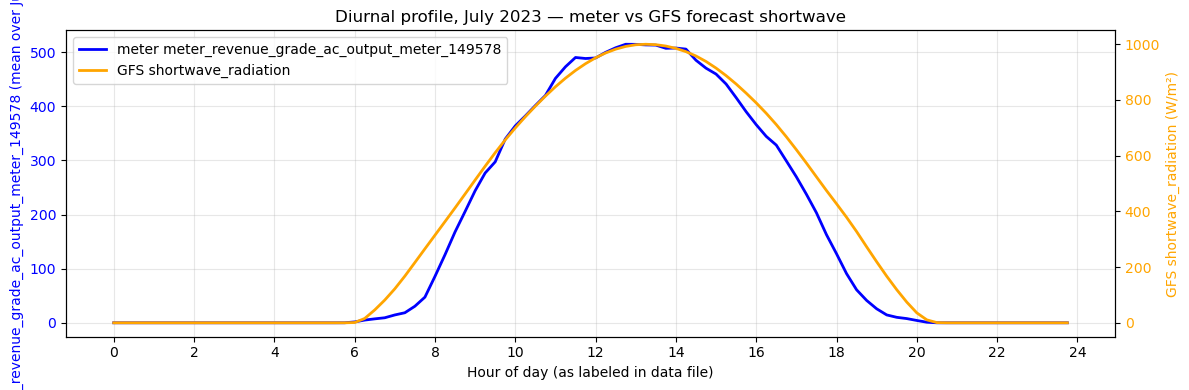

Peak hour, meter meter_revenue_grade_ac_output_meter_149578:           12.75
Peak hour, GFS shortwave_radiation: 13.25

✓ Alignment OK (offset = 0.50 hours, within 15-min grid jitter)


In [5]:
# Use July 2023 as a reference — mostly sunny, mid-summer, high signal
month = ('2023-07-01', '2023-08-01')
mt = meter_train[(meter_train['measured_on'] >= month[0]) & (meter_train['measured_on'] < month[1])].copy()
w  = weather_df [(weather_df ['measured_on'] >= month[0]) & (weather_df ['measured_on'] < month[1])].copy()

mt['hour_frac'] = mt['measured_on'].dt.hour + mt['measured_on'].dt.minute / 60
w ['hour_frac'] = w ['measured_on'].dt.hour + w ['measured_on'].dt.minute / 60

meter_hourly_profile = mt.groupby('hour_frac')[TARGET_COL].mean()
swr_hourly_profile   = w .groupby('hour_frac')['shortwave_radiation'].mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(meter_hourly_profile.index, meter_hourly_profile.values,
         'b-', lw=2, label=f'meter {TARGET_COL}')
ax1.set_xlabel('Hour of day (as labeled in data file)')
ax1.set_ylabel(f'{TARGET_COL} (mean over July 2023)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(range(0, 25, 2))
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(swr_hourly_profile.index, swr_hourly_profile.values,
         'orange', lw=2, label='GFS shortwave_radiation')
ax2.set_ylabel('GFS shortwave_radiation (W/m²)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Diurnal profile, July 2023 — meter vs GFS forecast shortwave')
plt.tight_layout()
plt.show()

print(f'Peak hour, meter {TARGET_COL}:           {meter_hourly_profile.idxmax():.2f}')
print(f'Peak hour, GFS shortwave_radiation: {swr_hourly_profile.idxmax():.2f}')

# Verdict
offset = abs(meter_hourly_profile.idxmax() - swr_hourly_profile.idxmax())
if offset < 1.5:
    print(f'\n✓ Alignment OK (offset = {offset:.2f} hours, within 15-min grid jitter)')
else:
    print(f'\n✗ MISALIGNED — offset = {offset:.2f} hours. Stop and investigate before proceeding.')

## 1e. Summary of what we have

If the alignment check passed, we're in good shape. Print final summary for the record.

In [ ]:
print('=== Step 1 complete. Summary: ===\n')
print(f'Meter training file:   {meter_train.shape[0]:,} rows, '
      f'{meter_train["measured_on"].min().date()} to {meter_train["measured_on"].max().date()}')
print(f'Meter 2024 file:       {meter_2024.shape[0]:,} rows, '
      f'{meter_2024["measured_on"].min().date()} to {meter_2024["measured_on"].max().date()}')
print(f'Weather forecast:      {weather_df.shape[0]:,} rows, '
      f'{weather_df["measured_on"].min().date()} to {weather_df["measured_on"].max().date()}')
print(f'Target column:         {TARGET_COL}')
print(f'Weather variables:     {len(WEATHER_VARS)}')
print(f'Timestamp convention:  Pacific local time (tz-naive), alignment verified')
print(f'\nNext step: aggregate 15-min data to hourly, explore the hourly target.')

=== Step 1 complete. Summary: ===

Meter training file:   240,062 rows, 2017-01-01 to 2023-11-09
Meter 2024 file:       32,155 rows, 2024-01-01 to 2024-11-30
Weather forecast:      91,584 rows, 2022-03-23 to 2024-10-31
Target column:         meter_revenue_grade_ac_output_meter_149578
Weather variables:     24
Timestamp convention:  Pacific local time (tz-naive), alignment verified

Next step: aggregate 15-min data to hourly, explore the hourly target.


# Step 2: Aggregate to Hourly and Explore the Target

**Goal.** Convert 15-minute data to hourly, merge meter and weather on hourly timestamps, and look at the resulting hourly energy target to confirm it behaves sensibly before we start modeling.

**Why hourly.** CAISO day-ahead bids are submitted hourly — 24 intervals per day, each bid separately. Training at hourly resolution directly matches the operational unit of the market.

**Aggregation convention.** Mean over the four 15-min samples in each hour. For power in kW, the hourly mean numerically equals the hourly energy in kWh. For weather variables (irradiance, cloud cover, etc.), mean is the natural aggregation.

**This notebook assumes you've just run Step 1** — `meter_train`, `meter_2024`, `weather_df`, `TARGET_COL`, `WEATHER_VARS` should still be in memory. If not, rerun Step 1 first.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safety check: make sure Step 1 objects are still in memory
for obj_name in ['meter_train', 'meter_2024', 'weather_df', 'TARGET_COL', 'WEATHER_VARS']:
    assert obj_name in dir(), f'{obj_name} not in memory — rerun Step 1 first'
print('Step 1 objects OK, proceeding.')

Step 1 objects OK, proceeding.


## 2a. Aggregate meter to hourly

Resample on the `measured_on` index to hourly intervals. We use the hour **start** as the timestamp (the hour labeled `13:00` covers 13:00–13:59:59, not 12:00–12:59:59). This matches CAISO's hour-ending / hour-beginning conventions — we just need to be consistent, and hour-beginning is more natural for `pandas`.

In [16]:
def to_hourly_mean(df, time_col='measured_on'):
    """Resample a 15-min DataFrame to hourly means using hour-beginning labels."""
    out = (
        df.set_index(time_col)
          .resample('1h', label='left', closed='left')
          .mean(numeric_only=True)
          .reset_index()
    )
    return out

# Require 4 samples per hour to accept it (some hours may have missing 15-min data)
def to_hourly_mean_strict(df, time_col='measured_on', min_samples=4):
    """Hourly mean, but only keep hours where we had at least min_samples non-NaN 15-min observations."""
    df2 = df.set_index(time_col)
    numeric = df2.select_dtypes(include=[np.number])
    means  = numeric.resample('1h', label='left', closed='left').mean()
    counts = numeric.resample('1h', label='left', closed='left').count()
    # A row is "valid" if every numeric column has >= min_samples observations
    valid = (counts >= min_samples).all(axis=1)
    return means[valid].reset_index()

meter_train_hr = to_hourly_mean_strict(meter_train)
meter_2024_hr  = to_hourly_mean_strict(meter_2024)
weather_hr     = to_hourly_mean_strict(weather_df)

# Rename target so subsequent code is cleaner
TARGET_HR = 'energy_kwh'
meter_train_hr = meter_train_hr.rename(columns={TARGET_COL: TARGET_HR})
meter_2024_hr  = meter_2024_hr.rename (columns={TARGET_COL: TARGET_HR})

print('Hourly row counts:')
print(f'  meter_train_hr: {len(meter_train_hr):,}  '
      f'{meter_train_hr["measured_on"].min()} -> {meter_train_hr["measured_on"].max()}')
print(f'  meter_2024_hr:  {len(meter_2024_hr):,}  '
      f'{meter_2024_hr["measured_on"].min()} -> {meter_2024_hr["measured_on"].max()}')
print(f'  weather_hr:     {len(weather_hr):,}  '
      f'{weather_hr["measured_on"].min()} -> {weather_hr["measured_on"].max()}')

# Quick sanity: hourly energy equals average power (in kW) — they're numerically the same since 1 kW for 1 h = 1 kWh.
# So the max hourly energy should be close to the max 15-min power.
print(f'\n  Max hourly energy:   {meter_train_hr[TARGET_HR].max():.1f} kWh')
print(f'  Mean hourly energy:  {meter_train_hr[TARGET_HR].mean():.1f} kWh')

Hourly row counts:
  meter_train_hr: 60,014  2017-01-01 01:00:00 -> 2023-11-09 22:00:00
  meter_2024_hr:  8,038  2024-01-01 01:00:00 -> 2024-11-30 23:00:00
  weather_hr:     22,896  2022-03-23 00:00:00 -> 2024-10-31 23:00:00

  Max hourly energy:   707.4 kWh
  Mean hourly energy:  153.1 kWh


## 2b. Merge meter + weather at hourly

Two datasets to prepare:
- **Train pool (2022-2023):** for the walk-forward training buffer
- **Test pool (2024):** for evaluation

We use `how='inner'` and drop NaN — clean starting point. Later we can revisit if data is being dropped for reasons we care about.

In [17]:
# Concatenate all meter hourly data for 2022-2023, then 2024 separately
meter_hr_all = pd.concat([meter_train_hr, meter_2024_hr], ignore_index=True).drop_duplicates(subset=['measured_on'])
meter_hr_all = meter_hr_all.sort_values('measured_on').reset_index(drop=True)

# Merge with weather (which only covers 2022-03-23 onward)
full = meter_hr_all.merge(weather_hr, on='measured_on', how='inner').dropna()
full = full.sort_values('measured_on').reset_index(drop=True)

# Split into train pool and test pool
train_end = pd.Timestamp('2023-12-31 23:59:59')
train_pool = full[full['measured_on'] <= train_end].copy().reset_index(drop=True)
test_pool  = full[full['measured_on'] >  train_end].copy().reset_index(drop=True)

print('After merge + inner join + dropna:')
print(f'  train_pool: {len(train_pool):,} hours  '
      f'{train_pool["measured_on"].min()} -> {train_pool["measured_on"].max()}')
print(f'  test_pool:  {len(test_pool):,} hours  '
      f'{test_pool["measured_on"].min()} -> {test_pool["measured_on"].max()}')

# Diagnostic: how much train/test coverage do we have per month?
print('\nTrain pool rows by month (sample):')
print(train_pool.set_index('measured_on').resample('MS').size().tail(12))
print('\nTest pool rows by month:')
print(test_pool.set_index('measured_on').resample('MS').size())

After merge + inner join + dropna:
  train_pool: 14,301 hours  2022-03-23 00:00:00 -> 2023-11-09 22:00:00
  test_pool:  7,318 hours  2024-01-01 01:00:00 -> 2024-10-31 23:00:00

Train pool rows by month (sample):
measured_on
2022-12-01    744
2023-01-01    744
2023-02-01    672
2023-03-01    743
2023-04-01    720
2023-05-01    720
2023-06-01    720
2023-07-01    744
2023-08-01    744
2023-09-01    720
2023-10-01    744
2023-11-01    215
Freq: MS, dtype: int64

Test pool rows by month:
measured_on
2024-01-01    743
2024-02-01    696
2024-03-01    743
2024-04-01    720
2024-05-01    744
2024-06-01    720
2024-07-01    744
2024-08-01    744
2024-09-01    720
2024-10-01    744
Freq: MS, dtype: int64


**Expected test pool:** a bit under 24 × 30 = 720 hours per month for Jan–Oct 2024, so roughly 7,000–7,200 total test hours. If we have significantly less, something dropped rows and we should investigate.

## 2c. Explore the hourly target

Three views of the target, in ascending complexity:
1. Distribution (histogram)
2. Hourly pattern by season
3. A few representative days (sunny vs cloudy)

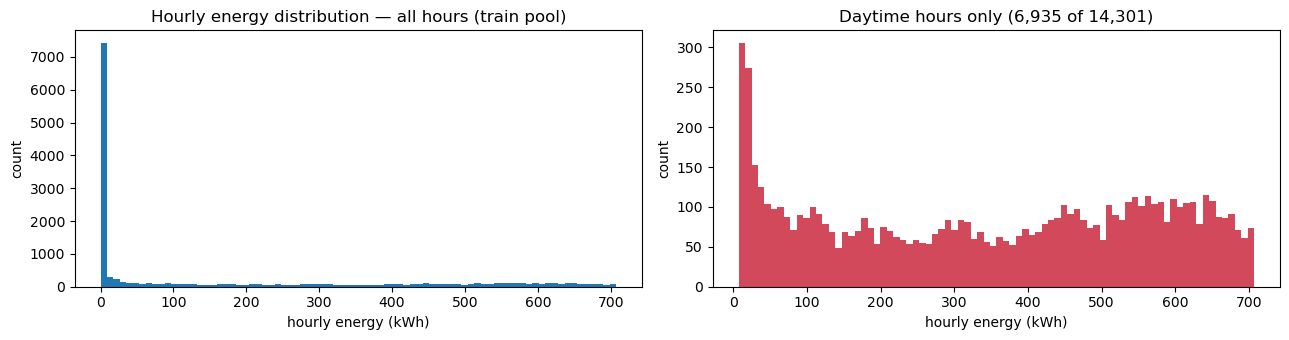

In [18]:
# --- View 1: distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(train_pool[TARGET_HR], bins=80)
axes[0].set_xlabel('hourly energy (kWh)'); axes[0].set_ylabel('count')
axes[0].set_title('Hourly energy distribution — all hours (train pool)')

# Daytime only: hours where some generation happens (above 1% of max)
day = train_pool[train_pool[TARGET_HR] > 0.01 * train_pool[TARGET_HR].max()]
axes[1].hist(day[TARGET_HR], bins=80, color='#d1495b')
axes[1].set_xlabel('hourly energy (kWh)'); axes[1].set_ylabel('count')
axes[1].set_title(f'Daytime hours only ({len(day):,} of {len(train_pool):,})')
plt.tight_layout(); plt.show()

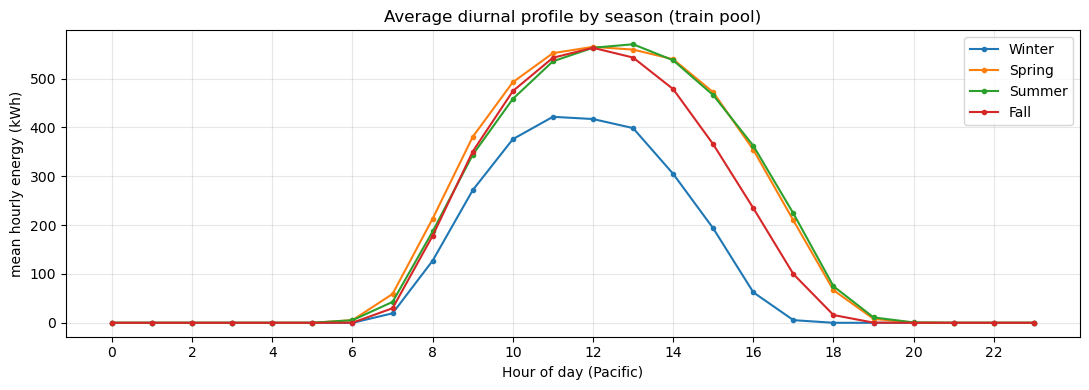

In [19]:
# --- View 2: average diurnal profile by season ---
tp = train_pool.copy()
tp['hour']  = tp['measured_on'].dt.hour
tp['month'] = tp['measured_on'].dt.month
tp['season'] = pd.cut(tp['month'], bins=[0, 2, 5, 8, 11, 12], labels=['Winter', 'Spring', 'Summer', 'Fall', 'Winter'],
                       ordered=False, right=True)

seasonal = tp.groupby(['season', 'hour'])[TARGET_HR].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(11, 4))
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    if season in seasonal.columns:
        ax.plot(seasonal.index, seasonal[season], marker='o', ms=3, label=season, lw=1.5)
ax.set_xlabel('Hour of day (Pacific)'); ax.set_ylabel('mean hourly energy (kWh)')
ax.set_title('Average diurnal profile by season (train pool)'); ax.legend()
ax.set_xticks(range(0, 24, 2)); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

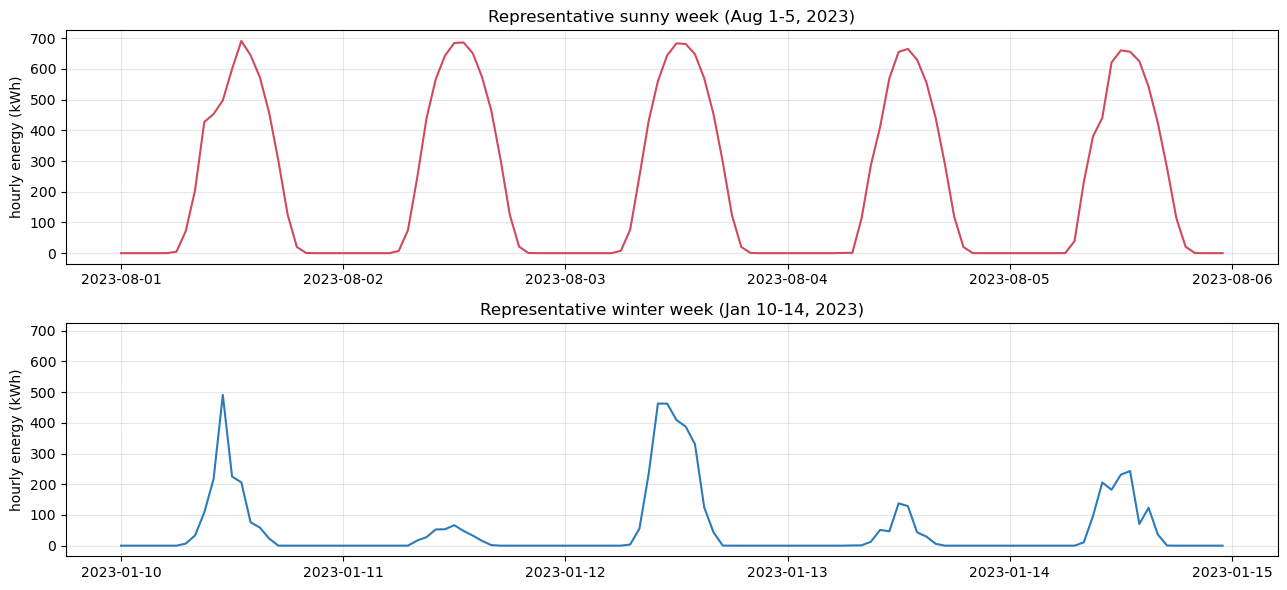

In [20]:
# --- View 3: five consecutive days (sunny) vs five days with weather (variable) ---
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharey=True)

# Probably-sunny stretch: early August 2023
sunny = train_pool[(train_pool['measured_on'] >= '2023-08-01') &
                    (train_pool['measured_on'] <  '2023-08-06')]
axes[0].plot(sunny['measured_on'], sunny[TARGET_HR], lw=1.5, color='#d1495b')
axes[0].set_title('Representative sunny week (Aug 1-5, 2023)')
axes[0].set_ylabel('hourly energy (kWh)'); axes[0].grid(True, alpha=0.3)

# Probably-variable: mid-January 2023
variable = train_pool[(train_pool['measured_on'] >= '2023-01-10') &
                      (train_pool['measured_on'] <  '2023-01-15')]
axes[1].plot(variable['measured_on'], variable[TARGET_HR], lw=1.5, color='#2b7bba')
axes[1].set_title('Representative winter week (Jan 10-14, 2023)')
axes[1].set_ylabel('hourly energy (kWh)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

**What to check in these plots:**
- Histogram: should show a big spike at 0 (nights) and a right-skewed distribution for daytime. Max around the plant's peak capacity.
- Diurnal profile: classic bell curves peaking ~12-13 in all seasons; summer curves should be higher and wider, winter lower and narrower.
- Representative weeks: the sunny week should show clean, similar bell curves day-to-day. The winter week may show irregular, ragged shapes reflecting cloud cover.

## 2d. Summary of Step 2

In [21]:
print('=== Step 2 complete. Summary: ===\n')
print(f'Hourly target column:     {TARGET_HR}')
print(f'Train pool:               {len(train_pool):,} hours    '
      f'({train_pool["measured_on"].min().date()} to {train_pool["measured_on"].max().date()})')
print(f'Test pool:                {len(test_pool):,} hours    '
      f'({test_pool["measured_on"].min().date()} to {test_pool["measured_on"].max().date()})')
print(f'Weather features:         {len(WEATHER_VARS)} variables at hourly resolution')
print(f'\nVariables available in train/test pools:')
print(f'  timestamp:  measured_on')
print(f'  target:     {TARGET_HR}')
print(f'  weather:    {", ".join(WEATHER_VARS[:6])}, ...')

print(f'\nNext step: feature engineering + baseline LightGBM on a simple holdout '
      f'(no walk-forward yet — just confirm the model learns something reasonable).')

=== Step 2 complete. Summary: ===

Hourly target column:     energy_kwh
Train pool:               14,301 hours    (2022-03-23 to 2023-11-09)
Test pool:                7,318 hours    (2024-01-01 to 2024-10-31)
Weather features:         24 variables at hourly resolution

Variables available in train/test pools:
  timestamp:  measured_on
  target:     energy_kwh
  weather:    temperature_2m, relative_humidity_2m, dew_point_2m, apparent_temperature, wind_speed_10m, wind_speed_80m, ...

Next step: feature engineering + baseline LightGBM on a simple holdout (no walk-forward yet — just confirm the model learns something reasonable).


# Diagnostic: where did the peak generation go?

The 15-minute data showed max 1,783 kW but the hourly aggregated max is 707 kWh. Let's figure out which of these is true:
1. The two meter files have different units/scales
2. The strict-aggregation filter is dropping the peak hours
3. The peak 1,783 was a single spike not representative of typical peaks

In [26]:
# Check 1: how do the two meter files compare on raw 15-min basis?
print('meter_train (15-min):')
print(f'  max:  {meter_train[TARGET_COL].max():.2f}')
print(f'  99th: {meter_train[TARGET_COL].quantile(0.99):.2f}')
print(f'  95th: {meter_train[TARGET_COL].quantile(0.95):.2f}')
print(f'  mean (daytime > 1): {meter_train[meter_train[TARGET_COL] > 1][TARGET_COL].mean():.2f}')
print()
print('meter_2024 (15-min):')
print(f'  max:  {meter_2024[TARGET_COL].max():.2f}')
print(f'  99th: {meter_2024[TARGET_COL].quantile(0.99):.2f}')
print(f'  95th: {meter_2024[TARGET_COL].quantile(0.95):.2f}')
print(f'  mean (daytime > 1): {meter_2024[meter_2024[TARGET_COL] > 1][TARGET_COL].mean():.2f}')

meter_train (15-min):
  max:  1783.68
  99th: 679.04
  95th: 612.48
  mean (daytime > 1): 326.53

meter_2024 (15-min):
  max:  705.92
  99th: 688.00
  95th: 627.84
  mean (daytime > 1): 323.27


In [23]:
# Check 2: non-strict hourly aggregation — does relaxing min_samples change anything?
import pandas as pd

def to_hourly_simple(df, time_col='measured_on'):
    return (df.set_index(time_col)
              .resample('1h', label='left', closed='left')
              .mean(numeric_only=True)
              .reset_index())

loose_train_hr = to_hourly_simple(meter_train).rename(columns={TARGET_COL: 'energy_kwh'})
loose_2024_hr  = to_hourly_simple(meter_2024 ).rename(columns={TARGET_COL: 'energy_kwh'})

print('Loose hourly aggregation (no min_samples filter):')
print(f'  meter_train_hr max: {loose_train_hr["energy_kwh"].max():.2f} kWh')
print(f'  meter_2024_hr max:  {loose_2024_hr["energy_kwh"].max():.2f} kWh')
print()
print('Strict hourly aggregation (your current pool, from Step 2):')
print(f'  train_pool max: {train_pool["energy_kwh"].max():.2f} kWh')
print(f'  test_pool max:  {test_pool["energy_kwh"].max():.2f} kWh')

Loose hourly aggregation (no min_samples filter):
  meter_train_hr max: 707.36 kWh
  meter_2024_hr max:  704.80 kWh

Strict hourly aggregation (your current pool, from Step 2):
  train_pool max: 707.36 kWh
  test_pool max:  704.80 kWh


In [24]:
# Check 3: find the timestamp of the 15-min peak and inspect that hour
idx = meter_train[TARGET_COL].idxmax()
peak_time = meter_train.loc[idx, 'measured_on']
peak_val  = meter_train.loc[idx, TARGET_COL]
print(f'Peak 15-min value: {peak_val:.2f} at {peak_time}')

# Show the hour containing this peak
hour_start = peak_time.floor('1h')
hour_end   = hour_start + pd.Timedelta(hours=1)
in_hour = meter_train[(meter_train['measured_on'] >= hour_start) & (meter_train['measured_on'] < hour_end)]
print(f'\nAll 15-min samples in the hour {hour_start} -> {hour_end}:')
print(in_hour[['measured_on', TARGET_COL]].to_string(index=False))
print(f'\nThat hour average: {in_hour[TARGET_COL].mean():.2f}')

Peak 15-min value: 1783.68 at 2018-02-18 12:30:00

All 15-min samples in the hour 2018-02-18 12:00:00 -> 2018-02-18 13:00:00:
        measured_on  meter_revenue_grade_ac_output_meter_149578
2018-02-18 12:00:00                                        0.00
2018-02-18 12:15:00                                        0.00
2018-02-18 12:30:00                                     1783.68
2018-02-18 12:45:00                                      679.04

That hour average: 615.68


In [25]:
# Check 4: distribution of peak hours across years
# If the plant's effective peak capacity changed over time, that'd show up here
meter_train_copy = meter_train.copy()
meter_train_copy['year'] = meter_train_copy['measured_on'].dt.year
meter_train_copy['month'] = meter_train_copy['measured_on'].dt.month

# Monthly 99th percentile of 15-min power
print('Monthly p99 of 15-min power (peak-ish values, by year x month):')
monthly_peaks = meter_train_copy.groupby(['year', 'month'])[TARGET_COL].quantile(0.99).unstack(level=0)
print(monthly_peaks.round(0))

Monthly p99 of 15-min power (peak-ish values, by year x month):
year    2017   2018   2019   2020   2021   2022   2023
month                                                 
1      595.0  628.0  579.0  633.0  633.0  664.0  696.0
2      602.0  672.0  588.0  705.0  705.0  705.0  678.0
3      602.0  682.0  636.0  668.0  703.0  706.0  703.0
4      602.0  662.0  687.0  692.0  668.0  703.0  702.0
5      595.0  680.0  682.0  662.0  703.0  705.0  693.0
6      567.0  635.0  671.0  696.0  693.0  659.0  694.0
7      561.0  619.0  675.0  655.0  654.0  673.0  632.0
8      552.0  562.0  662.0  659.0  651.0  674.0  679.0
9      550.0  604.0  676.0  620.0  653.0  695.0  652.0
10     650.0  703.0  692.0  597.0  701.0  672.0  658.0
11     647.0  614.0  633.0  623.0  668.0  680.0  641.0
12     619.0  612.0  607.0  609.0  642.0  656.0    NaN


# Step 3: Features, Persistence Baseline, and Simple-Holdout LightGBM

**Goal.** Build our feature set, establish a persistence baseline (day-1 as tomorrow's prediction), and train a single LightGBM on a simple holdout to confirm the setup is learning something reasonable. No walk-forward yet — that's Step 4.

**Why this order.** Walk-forward trains ~300 models. If the pipeline is broken (bad features, leaky target, etc.), we'd waste a lot of time. A single train→test evaluation here catches problems fast. Once it looks healthy, Step 4 upgrades to full walk-forward.

**Three things we'll have by the end:**
1. A feature-engineered DataFrame ready for modeling.
2. Persistence baseline metrics on the test pool.
3. Simple-holdout LightGBM metrics on the test pool.

**Assumes Steps 1 and 2 are already in memory** (`train_pool`, `test_pool`, `TARGET_HR`, `WEATHER_VARS`).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 60)

for obj in ['train_pool', 'test_pool', 'TARGET_HR', 'WEATHER_VARS']:
    assert obj in dir(), f'{obj} not in memory — rerun Steps 1 and 2'

## 3a. Feature engineering

Three feature families:

- **Time features.** Hour of day (sin/cos), day of year (sin/cos), month, day of week. Sin/cos encoding avoids the discontinuity at midnight / year boundary.
- **Forecast weather.** All 24 Open-Meteo variables as-is — LightGBM picks what matters.
- **Forecast-derived rolling features.** For the key irradiance channels, rolling means over the previous few hours (captures cloud buildup / dispersal patterns).

**Deliberately NOT included:** lags of the target. That would leak information across the walk-forward boundary and make the ML model unfair vs. persistence. The ML model only sees forecast weather; persistence uses only yesterday's target. They're in separate information regimes.

The one exception: we include `lag_24h_target` as a feature specifically in a third model (LightGBM + persistence hybrid) later. For now, pure-forecast LightGBM only.

In [28]:
def add_features(df, target_col=None):
    """Add time features and rolling irradiance features. Does not add target lags."""
    df = df.copy()
    t = df['measured_on']

    # Cyclical time encodings
    df['hour']    = t.dt.hour
    df['sin_hr']  = np.sin(2 * np.pi * t.dt.hour / 24)
    df['cos_hr']  = np.cos(2 * np.pi * t.dt.hour / 24)
    df['sin_doy'] = np.sin(2 * np.pi * t.dt.dayofyear / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * t.dt.dayofyear / 365.25)
    df['month']   = t.dt.month
    df['dow']     = t.dt.dayofweek

    # Rolling features on irradiance + cloud (safe: forecast weather is known 1 day ahead)
    for col in ['shortwave_radiation', 'direct_normal_irradiance',
                'global_tilted_irradiance', 'cloud_cover']:
        if col in df.columns:
            df[f'{col}_roll3h'] = df[col].rolling(3, min_periods=1).mean()
            df[f'{col}_roll6h'] = df[col].rolling(6, min_periods=1).mean()
    return df

train_pool_fe = add_features(train_pool)
test_pool_fe  = add_features(test_pool)

# Feature set: everything except timestamp and target
FEATURES = [c for c in train_pool_fe.columns if c not in ('measured_on', TARGET_HR)]
print(f'n_features = {len(FEATURES)}')
print('Features:', FEATURES)

n_features = 39
Features: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'wind_speed_10m', 'wind_speed_80m', 'wind_direction_10m', 'wind_direction_80m', 'wind_gusts_10m', 'shortwave_radiation', 'direct_radiation', 'direct_normal_irradiance', 'diffuse_radiation', 'global_tilted_irradiance', 'sunshine_duration', 'precipitation', 'snowfall', 'rain', 'cape', 'visibility', 'weather_code', 'cloud_cover', 'pressure_msl', 'surface_pressure', 'hour', 'sin_hr', 'cos_hr', 'sin_doy', 'cos_doy', 'month', 'dow', 'shortwave_radiation_roll3h', 'shortwave_radiation_roll6h', 'direct_normal_irradiance_roll3h', 'direct_normal_irradiance_roll6h', 'global_tilted_irradiance_roll3h', 'global_tilted_irradiance_roll6h', 'cloud_cover_roll3h', 'cloud_cover_roll6h']


## 3b. Persistence baseline

**Rule:** prediction for hour $h$ on day $d$ = actual generation at hour $h$ on day $d-1$.

This is the zero-effort forecast. If you knew nothing about weather or physics and just assumed tomorrow = today, this is what you'd get. Any model we build has to beat this to justify its existence.

**One subtlety.** To predict day $d$, we need the *previous calendar day's* same hour. If day $d-1$ happens to be missing from the data (gaps, filtered hours, etc.), we'd have NaN. We skip those cases in scoring — they're excluded from both the baseline and the ML evaluation.

In [29]:
def compute_persistence_prediction(df, target_col=TARGET_HR, time_col='measured_on'):
    """For each row at hour h on day d, return the target value at hour h on day d-1.
    NaN if the previous day's matching hour isn't present."""
    s = df.set_index(time_col)[target_col]
    # Shift by 24 hours: requires a regular hourly index. Reindex to make sure.
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='1h')
    s_reg = s.reindex(full_idx)
    s_lag = s_reg.shift(24)  # day-ahead persistence
    # Return a Series aligned to the original df's timestamps
    return s_lag.reindex(df[time_col]).values

# To do day-d-1 persistence for test_pool, we need the test pool PLUS the last day of the train pool
# (since Jan 1 2024's prediction uses Dec 31 2023's actuals).
combined = pd.concat([train_pool[['measured_on', TARGET_HR]].tail(48),  # last 2 days of train
                       test_pool[['measured_on', TARGET_HR]]],
                      ignore_index=True)
persistence_pred = compute_persistence_prediction(combined)
# Take only the test rows
persistence_test = persistence_pred[-len(test_pool):]

# How many predictions do we have?
n_valid = np.sum(~np.isnan(persistence_test))
print(f'Persistence predictions: {n_valid:,} / {len(test_pool):,} test hours have a valid day-1 reference')

Persistence predictions: 7,293 / 7,318 test hours have a valid day-1 reference


## 3c. Simple-holdout LightGBM

Train on the full train pool (2022-03 → 2023-11), predict the full test pool (2024 Jan–Oct), all in one shot. No walk-forward here — just one train, one predict.

This **underestimates** what walk-forward will achieve, because the model doesn't get to adapt to the 2024 test distribution as it goes. But it catches bugs fast and gives us a floor.

In [30]:
LGB_PARAMS = dict(
    objective='regression', metric='rmse',
    learning_rate=0.05, num_leaves=63, min_data_in_leaf=50,
    feature_fraction=0.9, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1,
)

# Internal early-stopping validation: last 10% of train pool
cut = int(len(train_pool_fe) * 0.9)
tr  = train_pool_fe.iloc[:cut]
va  = train_pool_fe.iloc[cut:]

print(f'Training LightGBM on {len(tr):,} rows, early-stop val on {len(va):,} rows...')
model = lgb.LGBMRegressor(n_estimators=2000, **LGB_PARAMS)
model.fit(
    tr[FEATURES], tr[TARGET_HR],
    eval_set=[(va[FEATURES], va[TARGET_HR])],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
print(f'Stopped at iteration {model.best_iteration_}')

lgb_pred = model.predict(test_pool_fe[FEATURES])
# Clip to non-negative — negative generation isn't physical
lgb_pred = np.clip(lgb_pred, 0, None)

Training LightGBM on 12,870 rows, early-stop val on 1,431 rows...
Stopped at iteration 75


## 3d. Head-to-head metrics

Both persistence and LightGBM evaluated on the same test hours (dropping any hour where persistence has no reference).

In [31]:
def metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_t, y_p = y_true[mask], y_pred[mask]
    day = y_t > 0.01 * np.nanmax(y_t)
    return [
        {'model': label, 'subset': 'overall', 'n': len(y_t),
         'MAE': mean_absolute_error(y_t, y_p),
         'RMSE': mean_squared_error(y_t, y_p) ** 0.5,
         'R2':  r2_score(y_t, y_p)},
        {'model': label, 'subset': 'daytime', 'n': int(day.sum()),
         'MAE': mean_absolute_error(y_t[day], y_p[day]),
         'RMSE': mean_squared_error(y_t[day], y_p[day]) ** 0.5,
         'R2':  r2_score(y_t[day], y_p[day])},
    ]

# Only score where persistence is valid (so both models see the same hours)
y_true = test_pool_fe[TARGET_HR].values
pers_valid = ~np.isnan(persistence_test)

all_metrics = (
    metrics(y_true[pers_valid], persistence_test[pers_valid], 'Persistence (day-1)') +
    metrics(y_true[pers_valid], lgb_pred[pers_valid],          'LightGBM (simple holdout)')
)

results = pd.DataFrame(all_metrics)
print('Test pool (2024 Jan-Oct) — head-to-head:')
print(results.to_string(index=False))

Test pool (2024 Jan-Oct) — head-to-head:
                    model  subset    n       MAE       RMSE       R2
      Persistence (day-1) overall 7293 33.867127  93.118351 0.834984
      Persistence (day-1) daytime 3663 65.428119 128.016806 0.665413
LightGBM (simple holdout) overall 7293 31.518720  61.626465 0.927725
LightGBM (simple holdout) daytime 3663 56.104599  80.359864 0.868158


## 3e. Visual comparison — representative week

Pick one week from test and show actual vs both predictions.

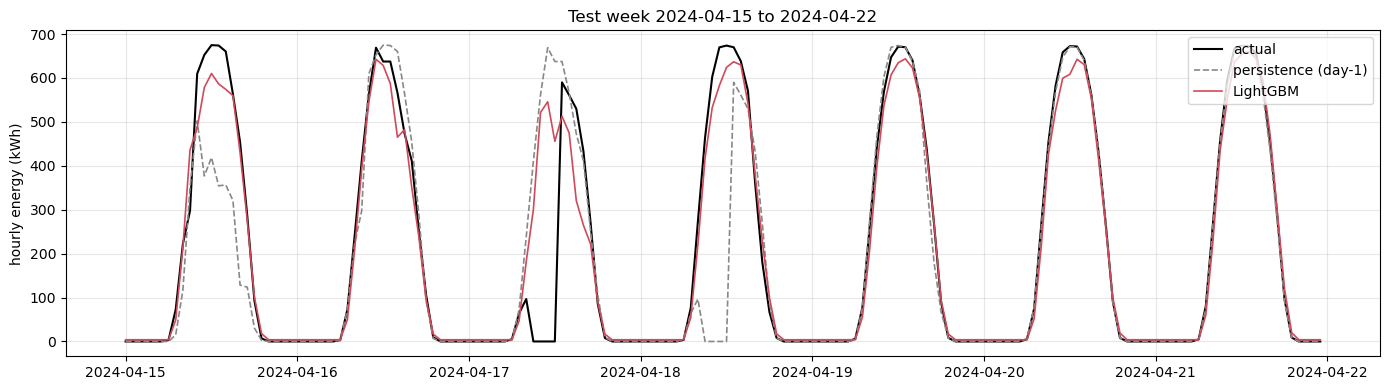

In [53]:
# Use a late-spring week in test — likely a mix of sunny and variable days
week_start = pd.Timestamp('2024-04-15')
week_end   = pd.Timestamp('2024-04-22')
mask = (test_pool_fe['measured_on'] >= week_start) & (test_pool_fe['measured_on'] < week_end)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_pool_fe.loc[mask, 'measured_on'], test_pool_fe.loc[mask, TARGET_HR],
        'k-', label='actual', lw=1.5)
ax.plot(test_pool_fe.loc[mask, 'measured_on'], persistence_test[mask],
        '--', color='#888', label='persistence (day-1)', lw=1.2)
ax.plot(test_pool_fe.loc[mask, 'measured_on'], lgb_pred[mask.values],
        color='#d1495b', label='LightGBM', lw=1.2)
ax.set_title(f'Test week {week_start.date()} to {week_end.date()}')
ax.set_ylabel('hourly energy (kWh)'); ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3f. Feature importance (LightGBM)

In [33]:
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain': model.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False).head(15)
print('Top 15 features by gain:')
print(imp.to_string(index=False))

Top 15 features by gain:
                        feature         gain
            shortwave_radiation 3.974687e+09
                         cos_hr 7.967646e+08
       global_tilted_irradiance 2.336349e+08
       direct_normal_irradiance 1.318406e+08
                        cos_doy 5.430851e+07
               direct_radiation 3.588494e+07
                        sin_doy 3.250274e+07
direct_normal_irradiance_roll6h 3.094016e+07
direct_normal_irradiance_roll3h 2.745965e+07
                           hour 2.683881e+07
           apparent_temperature 1.779264e+07
                    cloud_cover 1.562625e+07
              diffuse_radiation 1.509668e+07
                 temperature_2m 1.300429e+07
                            dow 1.104966e+07


## 3g. Summary of Step 3

In [ ]:
print('=== Step 3 complete. ===')
print()
print('What we built:')
print(f'  - Feature set: {len(FEATURES)} features (time + weather + rolling)')
print(f'  - Persistence baseline: tomorrow = today, per hour')
print(f'  - LightGBM simple-holdout model: trained on 2022-2023, tested on 2024')
print()
print('Key numbers (from 3d above):')
print('  - If LightGBM beats persistence on daytime R2 by a comfortable margin,')
print('    the feature engineering + modeling is working and we are ready for walk-forward.')
print('  - If persistence is close or ahead, something is off and we need to debug first.')
print()
print('Next step: full daily-cadence walk-forward evaluation (Step 4).')

=== Step 3 complete. ===

What we built:
  - Feature set: 39 features (time + weather + rolling)
  - Persistence baseline: tomorrow = today, per hour
  - LightGBM simple-holdout model: trained on 2022-2023, tested on 2024

Key numbers (from 3d above):
  - If LightGBM beats persistence on daytime R2 by a comfortable margin,
    the feature engineering + modeling is working and we are ready for walk-forward.
  - If persistence is close or ahead, something is off and we need to debug first.

Next step: full daily-cadence walk-forward evaluation (Step 4).


# Step 4: Daily Walk-Forward Evaluation

**Goal.** The operational benchmark. For each day $d$ in 2024, train on everything before $d$, predict $d$'s 24 hours, fold $d$'s actuals into training, advance. This simulates how a CAISO day-ahead forecasting system would actually be deployed: retrain daily as new data arrives.

**Why this matters.** The simple-holdout model in Step 3 never got to see 2024 data before predicting it. Walk-forward gives the model access to the latest days as they become historical — which is both more realistic (that's how operational systems work) and typically produces better metrics. The gap between simple-holdout (R² 0.868) and walk-forward is a measure of how much recency helps.

**Runtime.** ~305 refits over all of 2024. Budget 30-60 minutes.

**Assumes Steps 1-3 are in memory** (`train_pool_fe`, `test_pool_fe`, `TARGET_HR`, `FEATURES`, `LGB_PARAMS`, `persistence_test`).

In [37]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for obj in ['train_pool_fe', 'test_pool_fe', 'TARGET_HR', 'FEATURES', 'LGB_PARAMS', 'persistence_test']:
    assert obj in dir(), f'{obj} not in memory — rerun Steps 1-3'

## 4a. Walk-forward loop

For each calendar day in `test_pool_fe`:
1. Use all rows with timestamp strictly before that day as training buffer.
2. Split the buffer: last 10% for LightGBM's early-stopping validation, rest for fitting.
3. Fit LightGBM, predict the 24 hours of the current day.
4. Store predictions. No need to manually 'fold in' — the training buffer automatically grows because we slice from the full (train + test) combined DataFrame on each iteration.

Since refits are on 14k-21k rows, each should take ~5 seconds. We print progress every 30 days so you can see it's working.

In [38]:
# Build the combined DataFrame once so slicing is cheap
combined_fe = pd.concat([train_pool_fe, test_pool_fe], ignore_index=True)
combined_fe = combined_fe.sort_values('measured_on').reset_index(drop=True)

# Unique test days
test_days = pd.DatetimeIndex(test_pool_fe['measured_on'].dt.normalize().unique()).sort_values()
print(f'Walking forward over {len(test_days)} test days')

wf_pred = np.full(len(test_pool_fe), np.nan)
test_ts_array = test_pool_fe['measured_on'].values  # for fast indexing

start_time = time.time()
for i, day in enumerate(test_days):
    day_start = day
    day_end   = day + pd.Timedelta(days=1)

    # Training buffer: everything strictly before the current day
    train_buf = combined_fe[combined_fe['measured_on'] < day_start]
    if len(train_buf) < 500:
        continue  # unlikely but safe

    # Early-stopping split: last 10% chronologically
    cut = int(len(train_buf) * 0.9)
    tr, va = train_buf.iloc[:cut], train_buf.iloc[cut:]

    # Current-day window from test_pool_fe
    day_mask = (test_pool_fe['measured_on'] >= day_start) & (test_pool_fe['measured_on'] < day_end)
    window = test_pool_fe[day_mask]
    if len(window) == 0:
        continue

    # Fit
    model = lgb.LGBMRegressor(n_estimators=2000, **LGB_PARAMS)
    model.fit(
        tr[FEATURES], tr[TARGET_HR],
        eval_set=[(va[FEATURES], va[TARGET_HR])],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    # Predict
    y_hat = np.clip(model.predict(window[FEATURES]), 0, None)
    wf_pred[day_mask.values] = y_hat

    if (i + 1) % 30 == 0 or i == len(test_days) - 1:
        elapsed = time.time() - start_time
        eta = elapsed / (i + 1) * (len(test_days) - i - 1)
        print(f'  day {i+1}/{len(test_days)} ({day.date()}): '
              f'train_buf={len(train_buf):,}, best_iter={model.best_iteration_}, '
              f'elapsed={elapsed:.0f}s, eta={eta:.0f}s')

final_model = model
total_elapsed = time.time() - start_time
print(f'\nWalk-forward done in {total_elapsed/60:.1f} minutes')
print(f'Predictions filled: {np.sum(~np.isnan(wf_pred)):,} / {len(wf_pred):,}')

Walking forward over 305 test days
  day 30/305 (2024-01-30): train_buf=14,996, best_iter=78, elapsed=32s, eta=293s
  day 60/305 (2024-02-29): train_buf=15,716, best_iter=71, elapsed=63s, eta=258s
  day 90/305 (2024-03-30): train_buf=16,435, best_iter=69, elapsed=92s, eta=219s
  day 120/305 (2024-04-29): train_buf=17,155, best_iter=81, elapsed=122s, eta=188s
  day 150/305 (2024-05-29): train_buf=17,875, best_iter=107, elapsed=161s, eta=166s
  day 180/305 (2024-06-28): train_buf=18,595, best_iter=149, elapsed=201s, eta=139s
  day 210/305 (2024-07-28): train_buf=19,315, best_iter=89, elapsed=236s, eta=107s
  day 240/305 (2024-08-27): train_buf=20,035, best_iter=81, elapsed=269s, eta=73s
  day 270/305 (2024-09-26): train_buf=20,755, best_iter=59, elapsed=298s, eta=39s
  day 300/305 (2024-10-26): train_buf=21,475, best_iter=46, elapsed=324s, eta=5s
  day 305/305 (2024-10-31): train_buf=21,595, best_iter=47, elapsed=329s, eta=0s

Walk-forward done in 5.5 minutes
Predictions filled: 7,318 / 

## 4b. Three-way comparison: walk-forward vs simple-holdout vs persistence

In [39]:
def metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_t, y_p = y_true[mask], y_pred[mask]
    day = y_t > 0.01 * np.nanmax(y_t)
    return [
        {'model': label, 'subset': 'overall', 'n': len(y_t),
         'MAE': mean_absolute_error(y_t, y_p),
         'RMSE': mean_squared_error(y_t, y_p) ** 0.5,
         'R2':  r2_score(y_t, y_p)},
        {'model': label, 'subset': 'daytime', 'n': int(day.sum()),
         'MAE': mean_absolute_error(y_t[day], y_p[day]),
         'RMSE': mean_squared_error(y_t[day], y_p[day]) ** 0.5,
         'R2':  r2_score(y_t[day], y_p[day])},
    ]

y_true = test_pool_fe[TARGET_HR].values
# Only score where all three methods have a prediction (persistence can be NaN for day 1)
valid = ~np.isnan(persistence_test) & ~np.isnan(wf_pred) & ~np.isnan(lgb_pred)

all_metrics = (
    metrics(y_true[valid], persistence_test[valid], 'Persistence (day-1)') +
    metrics(y_true[valid], lgb_pred[valid],          'LightGBM (simple holdout)') +
    metrics(y_true[valid], wf_pred[valid],           'LightGBM (walk-forward)')
)
results = pd.DataFrame(all_metrics)
print('Test pool (2024 Jan-Oct) — three-way head-to-head:')
print(results.to_string(index=False))

Test pool (2024 Jan-Oct) — three-way head-to-head:
                    model  subset    n       MAE       RMSE       R2
      Persistence (day-1) overall 7293 33.867127  93.118351 0.834984
      Persistence (day-1) daytime 3663 65.428119 128.016806 0.665413
LightGBM (simple holdout) overall 7293 31.518720  61.626465 0.927725
LightGBM (simple holdout) daytime 3663 56.104599  80.359864 0.868158
  LightGBM (walk-forward) overall 7293 31.437829  61.403711 0.928246
  LightGBM (walk-forward) daytime 3663 55.157572  80.097422 0.869018


## 4c. Monthly breakdown

In [40]:
def monthly(y_true_s, y_pred, ts, label):
    tmp = pd.DataFrame({'t': ts, 'y': y_true_s, 'p': y_pred})
    tmp['year_month'] = tmp['t'].dt.to_period('M')
    day_threshold = 0.01 * tmp['y'].max()
    tmp = tmp[tmp['y'] > day_threshold].dropna()
    rows = []
    for ym, g in tmp.groupby('year_month'):
        if len(g) < 20: continue
        rows.append({
            'year_month': str(ym), 'model': label, 'n': len(g),
            'MAE':  mean_absolute_error(g['y'], g['p']),
            'RMSE': mean_squared_error(g['y'], g['p']) ** 0.5,
            'R2':   r2_score(g['y'], g['p']),
            'nMAE_pct': mean_absolute_error(g['y'], g['p']) / g['y'].mean() * 100,
        })
    return pd.DataFrame(rows)

ts = test_pool_fe['measured_on']
m_pers = monthly(y_true, persistence_test, ts, 'persistence')
m_wf   = monthly(y_true, wf_pred,           ts, 'walk_forward')

# Side-by-side R2
pivot_r2 = pd.DataFrame({
    'month':       m_wf['year_month'].values,
    'R2_pers':    m_pers['R2'].values,
    'R2_wf':       m_wf['R2'].values,
    'nMAE_pers':  m_pers['nMAE_pct'].values,
    'nMAE_wf':     m_wf['nMAE_pct'].values,
})
pivot_r2['R2_gain']  = pivot_r2['R2_wf']    - pivot_r2['R2_pers']
pivot_r2['nMAE_gain'] = pivot_r2['nMAE_pers'] - pivot_r2['nMAE_wf']
print('Monthly daytime comparison — walk-forward vs persistence:')
print(pivot_r2.to_string(index=False))

Monthly daytime comparison — walk-forward vs persistence:
  month   R2_pers    R2_wf  nMAE_pers   nMAE_wf   R2_gain  nMAE_gain
2024-01 -0.396193 0.590321  78.089139 42.019191  0.986513  36.069948
2024-02  0.139370 0.698666  51.584074 32.833742  0.559295  18.750331
2024-03  0.396389 0.807256  35.968036 23.213431  0.410867  12.754605
2024-04  0.620860 0.909715  22.081465 13.007722  0.288855   9.073743
2024-05  0.850901 0.948292  10.373647  9.998313  0.097390   0.375334
2024-06  0.916007 0.913382   8.214259 15.237420 -0.002626  -7.023161
2024-07  0.922359 0.869459   6.150145 17.611901 -0.052899 -11.461757
2024-08  0.875809 0.926826   8.329826  9.956441  0.051016  -1.626615
2024-09  0.942547 0.963246   6.548629  7.771727  0.020700  -1.223098
2024-10  0.551816 0.817704  22.699058 16.333898  0.265888   6.365160


## 4d. Visualizations

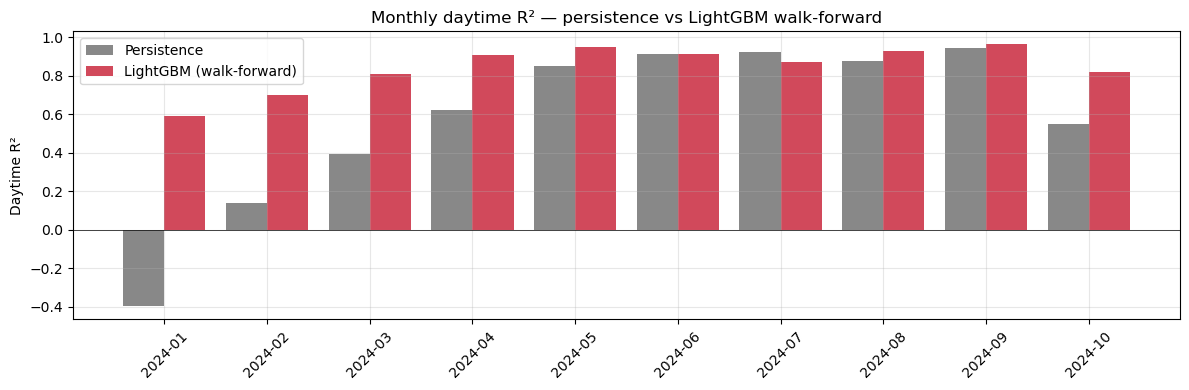

In [41]:
# Monthly R² bar chart — the presentation figure
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(pivot_r2))
w = 0.4
ax.bar(x - w/2, pivot_r2['R2_pers'], width=w, color='#888', label='Persistence')
ax.bar(x + w/2, pivot_r2['R2_wf'],    width=w, color='#d1495b', label='LightGBM (walk-forward)')
ax.set_xticks(x); ax.set_xticklabels(pivot_r2['month'], rotation=45)
ax.set_ylabel('Daytime R²'); ax.set_title('Monthly daytime R² — persistence vs LightGBM walk-forward')
ax.legend(); ax.axhline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

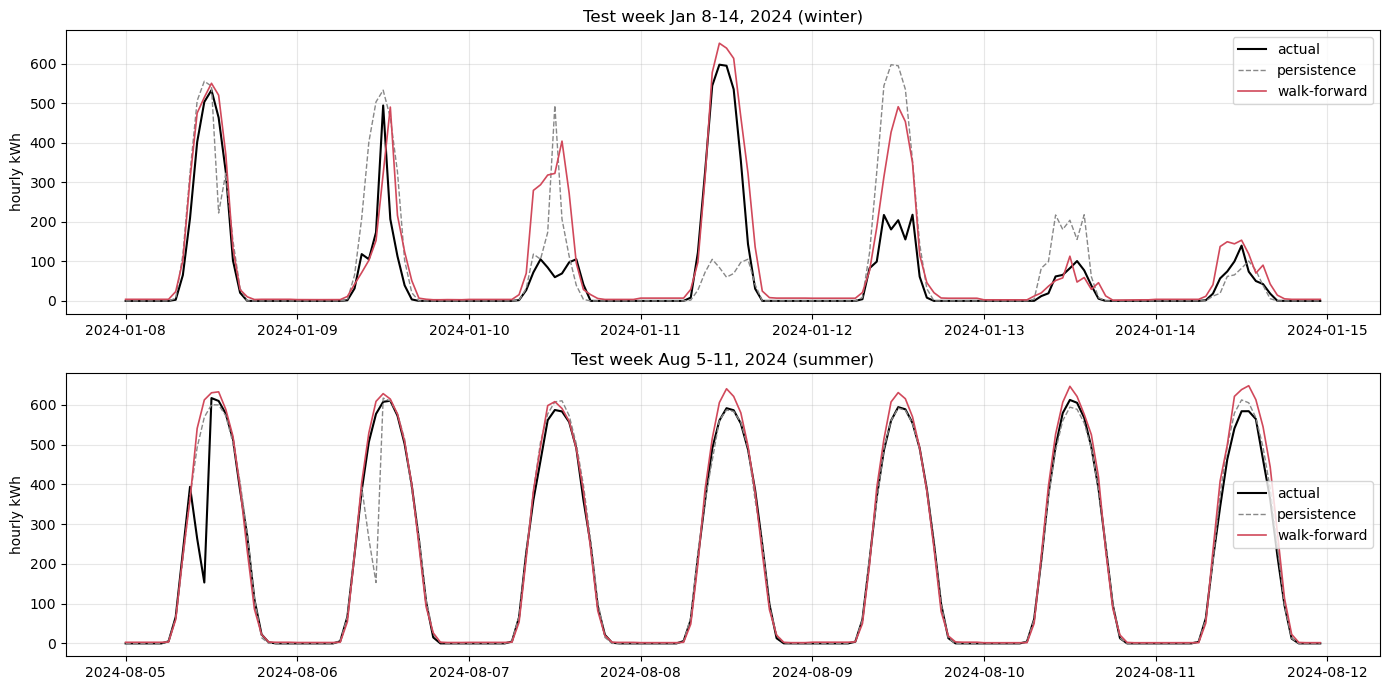

In [42]:
# Representative weeks — sunny August vs stormy January
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# January storm week
m1 = (test_pool_fe['measured_on'] >= '2024-01-08') & (test_pool_fe['measured_on'] < '2024-01-15')
axes[0].plot(test_pool_fe.loc[m1, 'measured_on'], y_true[m1],           'k-', label='actual',     lw=1.5)
axes[0].plot(test_pool_fe.loc[m1, 'measured_on'], persistence_test[m1], '--', color='#888', label='persistence', lw=1)
axes[0].plot(test_pool_fe.loc[m1, 'measured_on'], wf_pred[m1.values],   color='#d1495b', label='walk-forward', lw=1.2)
axes[0].set_title('Test week Jan 8-14, 2024 (winter)')
axes[0].set_ylabel('hourly kWh'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# August clear week
m2 = (test_pool_fe['measured_on'] >= '2024-08-05') & (test_pool_fe['measured_on'] < '2024-08-12')
axes[1].plot(test_pool_fe.loc[m2, 'measured_on'], y_true[m2],           'k-', label='actual',     lw=1.5)
axes[1].plot(test_pool_fe.loc[m2, 'measured_on'], persistence_test[m2], '--', color='#888', label='persistence', lw=1)
axes[1].plot(test_pool_fe.loc[m2, 'measured_on'], wf_pred[m2.values],   color='#d1495b', label='walk-forward', lw=1.2)
axes[1].set_title('Test week Aug 5-11, 2024 (summer)')
axes[1].set_ylabel('hourly kWh'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4e. Summary

In [43]:
print('=== Step 4 complete. ===\n')
print(f'Walk-forward refits: {len(test_days)} days, runtime {total_elapsed/60:.1f} minutes')
print()
print('Headline results (test pool, 2024 Jan-Oct, daytime only):')
day_only = results[results['subset'] == 'daytime'][['model', 'MAE', 'RMSE', 'R2']]
print(day_only.to_string(index=False))
print()
print('Monthly R² gain (walk-forward vs persistence):')
print(pivot_r2[['month', 'R2_pers', 'R2_wf', 'R2_gain']].to_string(index=False))
print()
print(f'Mean monthly R² gain from ML:     {pivot_r2["R2_gain"].mean():.3f}')
print(f'Mean monthly nMAE% reduction:     {pivot_r2["nMAE_gain"].mean():.2f}')
print()
print('Next step: Step 5 — diagnostics + writeup for presentation.')

=== Step 4 complete. ===

Walk-forward refits: 305 days, runtime 5.5 minutes

Headline results (test pool, 2024 Jan-Oct, daytime only):
                    model       MAE       RMSE       R2
      Persistence (day-1) 65.428119 128.016806 0.665413
LightGBM (simple holdout) 56.104599  80.359864 0.868158
  LightGBM (walk-forward) 55.157572  80.097422 0.869018

Monthly R² gain (walk-forward vs persistence):
  month   R2_pers    R2_wf   R2_gain
2024-01 -0.396193 0.590321  0.986513
2024-02  0.139370 0.698666  0.559295
2024-03  0.396389 0.807256  0.410867
2024-04  0.620860 0.909715  0.288855
2024-05  0.850901 0.948292  0.097390
2024-06  0.916007 0.913382 -0.002626
2024-07  0.922359 0.869459 -0.052899
2024-08  0.875809 0.926826  0.051016
2024-09  0.942547 0.963246  0.020700
2024-10  0.551816 0.817704  0.265888

Mean monthly R² gain from ML:     0.263
Mean monthly nMAE% reduction:     6.21

Next step: Step 5 — diagnostics + writeup for presentation.


# Step 4.5: Two Investigations Before Writeup

Two loose ends from Step 4 results:

1. **Walk-forward vs simple-holdout tied at +0.001 R².** Is walk-forward genuinely not helping, or am I missing something?
2. **July 2024 is the one month ML lost to persistence.** Can clear-sky normalization recover it?

Investigation 2 is the longer one (needs another walk-forward). Investigation 1 takes seconds. We'll do 1 first, then 2.

**Assumes Steps 1-4 in memory:** `train_pool_fe`, `test_pool_fe`, `TARGET_HR`, `FEATURES`, `LGB_PARAMS`, `lgb_pred`, `wf_pred`, `persistence_test`, `y_true`, `final_model`, `combined_fe`.

In [44]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for obj in ['train_pool_fe', 'test_pool_fe', 'TARGET_HR', 'FEATURES', 'LGB_PARAMS',
            'lgb_pred', 'wf_pred', 'persistence_test', 'y_true', 'combined_fe']:
    assert obj in dir(), f'{obj} not in memory'

## Investigation 1: Why do walk-forward and simple-holdout tie?

Hypothesis options:
- **A.** The models are making essentially identical predictions (walk-forward isn't meaningfully different)
- **B.** The predictions differ, but the differences average out in aggregate metrics
- **C.** Walk-forward is helping in some months and hurting in others, canceling out

Quick diagnostics to distinguish these.

In [45]:
# Diff analysis
diff = wf_pred - lgb_pred
valid = ~np.isnan(lgb_pred) & ~np.isnan(wf_pred)
diff_valid = diff[valid]

print('Prediction differences (walk-forward - simple-holdout):')
print(f'  mean:   {np.mean(diff_valid):.3f} kWh')
print(f'  median: {np.median(diff_valid):.3f} kWh')
print(f'  std:    {np.std(diff_valid):.3f} kWh')
print(f'  min:    {np.min(diff_valid):.3f} kWh')
print(f'  max:    {np.max(diff_valid):.3f} kWh')
print()
# Correlation: if ~1.0, models are basically identical
corr = np.corrcoef(lgb_pred[valid], wf_pred[valid])[0, 1]
print(f'Correlation between walk-forward and holdout predictions: {corr:.4f}')

Prediction differences (walk-forward - simple-holdout):
  mean:   0.343 kWh
  median: 0.028 kWh
  std:    12.133 kWh
  min:    -104.336 kWh
  max:    86.691 kWh

Correlation between walk-forward and holdout predictions: 0.9985


In [46]:
# Monthly comparison — where does walk-forward actually help or hurt?
def month_r2(y_true_s, y_pred, ts):
    tmp = pd.DataFrame({'t': ts, 'y': y_true_s, 'p': y_pred})
    tmp['ym'] = tmp['t'].dt.to_period('M')
    day_threshold = 0.01 * tmp['y'].max()
    tmp = tmp[tmp['y'] > day_threshold].dropna()
    return tmp.groupby('ym').apply(
        lambda g: pd.Series({'R2': r2_score(g['y'], g['p']), 'n': len(g)})
    )

ts = test_pool_fe['measured_on']
r2_holdout = month_r2(y_true, lgb_pred, ts)
r2_wf      = month_r2(y_true, wf_pred,  ts)

cmp = pd.DataFrame({
    'R2_holdout': r2_holdout['R2'],
    'R2_walk_forward': r2_wf['R2'],
})
cmp['gain_from_walk_forward'] = cmp['R2_walk_forward'] - cmp['R2_holdout']
print('Walk-forward vs simple-holdout by month (daytime R²):')
print(cmp.round(4).to_string())
print(f'\nMean gain: {cmp["gain_from_walk_forward"].mean():+.4f}')
print(f'Max gain:  {cmp["gain_from_walk_forward"].max():+.4f}  in {cmp["gain_from_walk_forward"].idxmax()}')
print(f'Min gain:  {cmp["gain_from_walk_forward"].min():+.4f}  in {cmp["gain_from_walk_forward"].idxmin()}')

Walk-forward vs simple-holdout by month (daytime R²):
         R2_holdout  R2_walk_forward  gain_from_walk_forward
ym                                                          
2024-01      0.5825           0.5903                  0.0078
2024-02      0.6947           0.6987                  0.0040
2024-03      0.8009           0.8073                  0.0064
2024-04      0.9137           0.9097                 -0.0040
2024-05      0.9472           0.9483                  0.0011
2024-06      0.9108           0.9134                  0.0026
2024-07      0.8725           0.8695                 -0.0030
2024-08      0.9249           0.9268                  0.0019
2024-09      0.9473           0.9632                  0.0159
2024-10      0.8389           0.8177                 -0.0212

Mean gain: +0.0011
Max gain:  +0.0159  in 2024-09
Min gain:  -0.0212  in 2024-10


**Interpretation guide.**
- If correlation > 0.995 and std of diffs < 5 kWh → models are nearly identical (hypothesis A)
- If correlation in 0.95-0.99 range and some months gain/lose significantly → hypothesis C, walk-forward helps sometimes and hurts sometimes
- If correlation in 0.90-0.95 range but monthly R² almost identical → hypothesis B, individual predictions differ but balance out

## Investigation 2: Does clear-sky normalization fix July?

Walk-forward again, but with a transformed target: k_index = actual_power / clear_sky_reference_power. At prediction time we multiply predicted k by clear-sky reference to recover power. This reshapes the target to be more stationary year-round and can make the model more robust to site-efficiency anomalies.

**Need `pvlib`** — install if not already: `pip install pvlib`

In [47]:
# Compute clear-sky GHI for the full time range
import pvlib
from pvlib.location import Location

LAT, LON = 38.9963, -122.1341
SITE_TZ = 'America/Los_Angeles'

def compute_cs_ghi(timestamps_naive, tz=SITE_TZ, lat=LAT, lon=LON):
    loc = Location(lat, lon, tz=tz)
    idx = pd.DatetimeIndex(timestamps_naive).tz_localize(tz, nonexistent='NaT', ambiguous='NaT')
    cs = loc.get_clearsky(idx, model='ineichen')
    return cs['ghi'].values

# Add cs_ghi to both train_pool_fe and test_pool_fe
combined_k = combined_fe.copy()
combined_k['cs_ghi'] = compute_cs_ghi(combined_k['measured_on'])

# Estimate site capacity from training portion only (avoid test leakage)
train_mask = combined_k['measured_on'] <= pd.Timestamp('2023-12-31 23:59:59')
cs_big = (combined_k['cs_ghi'] > 200) & train_mask
ratios = combined_k.loc[cs_big, TARGET_HR] / combined_k.loc[cs_big, 'cs_ghi']
SITE_COEF = np.percentile(ratios, 99)
print(f'SITE_CAPACITY_COEF (99th percentile, from training data only): {SITE_COEF:.4f}')

# Derive k_index and k_index_clipped
CS_FLOOR = 20.0  # W/m^2 — below this, treat as night
combined_k['cs_power']         = combined_k['cs_ghi'] * SITE_COEF
combined_k['k_index']          = np.where(combined_k['cs_ghi'] > CS_FLOOR,
                                            combined_k[TARGET_HR] / combined_k['cs_power'],
                                            np.nan)
combined_k['k_index_clipped']  = combined_k['k_index'].clip(lower=0.0, upper=1.3)

# Add gfs_over_cs (forecast clear-sky index proxy) — useful feature
combined_k['gfs_over_cs'] = (combined_k['shortwave_radiation'] / combined_k['cs_ghi'].clip(lower=1.0)).clip(0, 2.0)

K_FEATURES = FEATURES + ['cs_ghi', 'gfs_over_cs']
print(f'n_features for k model: {len(K_FEATURES)}')

SITE_CAPACITY_COEF (99th percentile, from training data only): 1.7338
n_features for k model: 41


In [48]:
# Walk-forward with k_index_clipped as target
test_mask = combined_k['measured_on'] > pd.Timestamp('2023-12-31 23:59:59')
test_k = combined_k[test_mask].reset_index(drop=True)

test_days = pd.DatetimeIndex(test_k['measured_on'].dt.normalize().unique()).sort_values()
print(f'Walking forward over {len(test_days)} test days (clear-sky target)')

wf_pred_cs    = np.full(len(test_k), np.nan)
wf_pred_k_raw = np.full(len(test_k), np.nan)  # raw k predictions (for debug)

start_time = time.time()
for i, day in enumerate(test_days):
    day_start = day
    day_end   = day + pd.Timedelta(days=1)
    train_buf = combined_k[combined_k['measured_on'] < day_start]
    # Only train on daytime rows where k is defined
    train_day = train_buf.dropna(subset=['k_index_clipped'])
    if len(train_day) < 500: continue
    cut = int(len(train_day) * 0.9)
    tr, va = train_day.iloc[:cut], train_day.iloc[cut:]

    day_mask = (test_k['measured_on'] >= day_start) & (test_k['measured_on'] < day_end)
    window = test_k[day_mask]
    if len(window) == 0: continue

    model = lgb.LGBMRegressor(n_estimators=2000, **LGB_PARAMS)
    model.fit(tr[K_FEATURES], tr['k_index_clipped'],
              eval_set=[(va[K_FEATURES], va['k_index_clipped'])],
              callbacks=[lgb.early_stopping(50, verbose=False)])

    k_hat = model.predict(window[K_FEATURES])
    p_hat = k_hat * window['cs_power'].values
    night = window['cs_ghi'].values <= CS_FLOOR
    p_hat[night] = 0.0
    p_hat = np.clip(p_hat, 0, None)

    wf_pred_cs[day_mask.values]    = p_hat
    wf_pred_k_raw[day_mask.values] = k_hat

    if (i + 1) % 30 == 0 or i == len(test_days) - 1:
        elapsed = time.time() - start_time
        print(f'  day {i+1}/{len(test_days)}: elapsed={elapsed:.0f}s')

print(f'Clear-sky walk-forward done in {(time.time()-start_time)/60:.1f} min')

Walking forward over 305 test days (clear-sky target)
  day 30/305: elapsed=33s
  day 60/305: elapsed=67s
  day 90/305: elapsed=98s
  day 120/305: elapsed=135s
  day 150/305: elapsed=173s
  day 180/305: elapsed=201s
  day 210/305: elapsed=222s
  day 240/305: elapsed=243s
  day 270/305: elapsed=266s
  day 300/305: elapsed=290s
  day 305/305: elapsed=294s
Clear-sky walk-forward done in 4.9 min


In [49]:
# Three-way monthly comparison: persistence, raw-target walk-forward, clear-sky walk-forward
ts_k = test_k['measured_on']
y_true_k = test_k[TARGET_HR].values

r2_pers_k = month_r2(y_true_k, persistence_test[:len(y_true_k)], ts_k)
r2_wf_raw = month_r2(y_true_k, wf_pred,                           ts_k)
r2_wf_cs  = month_r2(y_true_k, wf_pred_cs,                        ts_k)

full_cmp = pd.DataFrame({
    'R2_persistence':   r2_pers_k['R2'],
    'R2_raw_target':   r2_wf_raw['R2'],
    'R2_clearsky':     r2_wf_cs['R2'],
})
full_cmp['cs_vs_raw'] = full_cmp['R2_clearsky'] - full_cmp['R2_raw_target']
print('Monthly daytime R² — all three models:')
print(full_cmp.round(4).to_string())
print()
print(f'Mean R² by model:')
print(f'  persistence:   {full_cmp["R2_persistence"].mean():.4f}')
print(f'  raw target:    {full_cmp["R2_raw_target"].mean():.4f}')
print(f'  clear-sky:     {full_cmp["R2_clearsky"].mean():.4f}')
print(f'\nJuly specifically (the one month where ML lost):')
print(f'  raw target:    {full_cmp.loc["2024-07", "R2_raw_target"]:.4f}')
print(f'  clear-sky:     {full_cmp.loc["2024-07", "R2_clearsky"]:.4f}')
print(f'  delta:         {full_cmp.loc["2024-07", "cs_vs_raw"]:+.4f}')

Monthly daytime R² — all three models:
         R2_persistence  R2_raw_target  R2_clearsky  cs_vs_raw
ym                                                            
2024-01         -0.3962         0.5903       0.5838    -0.0065
2024-02          0.1394         0.6987       0.7207     0.0220
2024-03          0.3964         0.8073       0.8090     0.0017
2024-04          0.6209         0.9097       0.9065    -0.0032
2024-05          0.8509         0.9483       0.9587     0.0104
2024-06          0.9160         0.9134       0.9271     0.0138
2024-07          0.9224         0.8695       0.9171     0.0477
2024-08          0.8758         0.9268       0.9125    -0.0143
2024-09          0.9425         0.9632       0.9464    -0.0168
2024-10          0.5518         0.8177       0.8106    -0.0071

Mean R² by model:
  persistence:   0.5820
  raw target:    0.8445
  clear-sky:     0.8493

July specifically (the one month where ML lost):
  raw target:    0.8695
  clear-sky:     0.9171
  delta:        

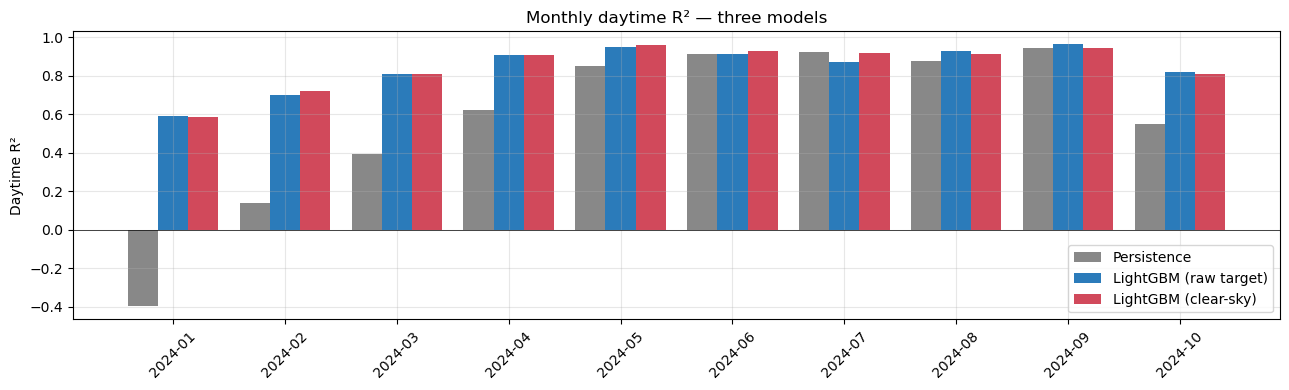

In [50]:
# Bar chart: three models side by side
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(full_cmp))
w = 0.27
ax.bar(x - w, full_cmp['R2_persistence'], width=w, color='#888',    label='Persistence')
ax.bar(x,     full_cmp['R2_raw_target'],  width=w, color='#2b7bba', label='LightGBM (raw target)')
ax.bar(x + w, full_cmp['R2_clearsky'],    width=w, color='#d1495b', label='LightGBM (clear-sky)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([str(m) for m in full_cmp.index], rotation=45)
ax.set_ylabel('Daytime R²'); ax.set_title('Monthly daytime R² — three models')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Summary

After running both investigations:
1. The Investigation 1 correlation + monthly diffs tell us whether walk-forward adds value anywhere specific
2. The Investigation 2 July comparison tells us whether clear-sky normalization is worth adopting as the default

Based on these, we'll decide the writeup framing in Step 5:
- If clear-sky strictly dominates raw: lead with clear-sky model, mention raw as ablation
- If clear-sky fixes July but hurts other months: present as two-model strategy
- If clear-sky doesn't help meaningfully: stick with raw target and note July as a known limitation

# Save predictions for Step 5

Run this **after** both Step 4 and Step 4.5 have completed. It saves the key arrays to disk so Step 5 can load them without re-running the full pipeline.

Files written to `./results/`:
- `predictions.npz` — all prediction arrays and ground truth
- `metadata.json` — run metadata (dates, site info, coefficients)

In [51]:
import os
import json
import numpy as np

os.makedirs('./results', exist_ok=True)

# All the arrays Step 5 needs
np.savez('./results/predictions.npz',
    timestamps        = test_pool_fe['measured_on'].values,
    y_true            = y_true,
    persistence_pred  = persistence_test,
    lgb_holdout_pred  = lgb_pred,
    lgb_wf_pred       = wf_pred,
    lgb_wf_cs_pred    = wf_pred_cs,
)

metadata = {
    'site': {
        'name': 'OEDI System 2107',
        'location': 'Arbuckle, CA',
        'lat': 38.9963, 'lon': -122.1341,
        'timezone': 'America/Los_Angeles',
        'peak_capacity_kw': 707,
    },
    'data': {
        'train_range': ['2022-03-23', '2023-11-09'],
        'test_range':  ['2024-01-01', '2024-10-31'],
        'resolution':  'hourly (aggregated from 15-min)',
        'weather_source': 'Open-Meteo previous-runs-api, GFS seamless, previous_day=1',
        'n_features_raw': len(FEATURES),
        'n_features_cs':  len(K_FEATURES) if 'K_FEATURES' in dir() else None,
    },
    'walk_forward': {
        'cadence_days': 1,
        'n_test_days': len(test_days),
        'runtime_seconds_raw': round(float(total_elapsed), 1),
    },
    'clear_sky': {
        'site_capacity_coef': float(SITE_COEF) if 'SITE_COEF' in dir() else None,
        'cs_floor_wm2': 20.0,
        'pvlib_model': 'ineichen',
    },
    'lgb_params': LGB_PARAMS,
}

with open('./results/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print('Saved:')
print('  ./results/predictions.npz')
print('  ./results/metadata.json')
print(f'\nArrays in npz file: {sorted(np.load("./results/predictions.npz").files)}')

Saved:
  ./results/predictions.npz
  ./results/metadata.json

Arrays in npz file: ['lgb_holdout_pred', 'lgb_wf_cs_pred', 'lgb_wf_pred', 'persistence_pred', 'timestamps', 'y_true']
